# The corrected-likelihood optimizer landscape

This notebook consolidates the exploratory analysis behind the multistart figure of
Section 3.5 of the report. It is structured around three questions:

1. **Is the empirical objective globally concave?** No. The bowl deforms as the noise
   rates grow; the per-observation function $\log q_i(\eta)$ has convex tails when
   $\delta, \varepsilon > 0$, and that non-concavity can produce multiple finite-sample
   stationary points.
2. **What does L-BFGS-B actually find?** On the breast-cancer training fold at
   $\varepsilon = \delta = 0.20$ the multistart finds **exactly two distinct interior
   stationary points**, both strict local maxima.
3. **Why does the majority of starts converge to the worse local max?** Because the
   two maxima are nearly collinear from the origin, the corrected likelihood's
   gradient on this near-separating data predominantly points toward the further-out
   local max, and that max has a soft basin that catches the bulk of random starts.

All randomness flows from `SEED = 6114` so every result is reproducible.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import statsmodels.api as sm

from helper_functions.corrected_mle import (
    SEED, H, fit_corr, flip_labels, neg_logL, grad_L, numeric_hess,
)
from helper_functions.styling import set_latex_plot_style
from multistart_optimality import make_synth, make_breast, multistart

warnings.filterwarnings('ignore')
set_latex_plot_style(use_tex=False, figure_size=(7.0, 4.4))

print(f'SEED = {SEED}')

SEED = 6114


## 1. The empirical objective deforms with noise

In ordinary logistic regression, $\beta \mapsto \ell_n(\beta)$ is globally concave
because $\eta \mapsto \log H(\eta)$ has second derivative $-H(1-H) \le 0$ everywhere.

In the corrected case, $q_i(\eta) = \delta + a H(\eta)$ no longer ranges over $(0,1)$:
it floors at $\delta$ as $\eta \to -\infty$ and ceilings at $1-\varepsilon$ as $\eta \to +\infty$.
The penalty for confident-wrong predictions becomes finite, and the per-observation
log-density develops **convex tails** in $\eta$. The cell below visualises this for the
single-covariate synthetic model of Section 5.2 at three noise levels.

At $n = 1000$ the empirical surface stays nearly concave at moderate noise --- you need
fewer observations or higher noise to see the tail non-concavity directly. What you can
see clearly is that the bowl flattens and the contours stretch as $\varepsilon = \delta$
grows from 0 to 0.40.

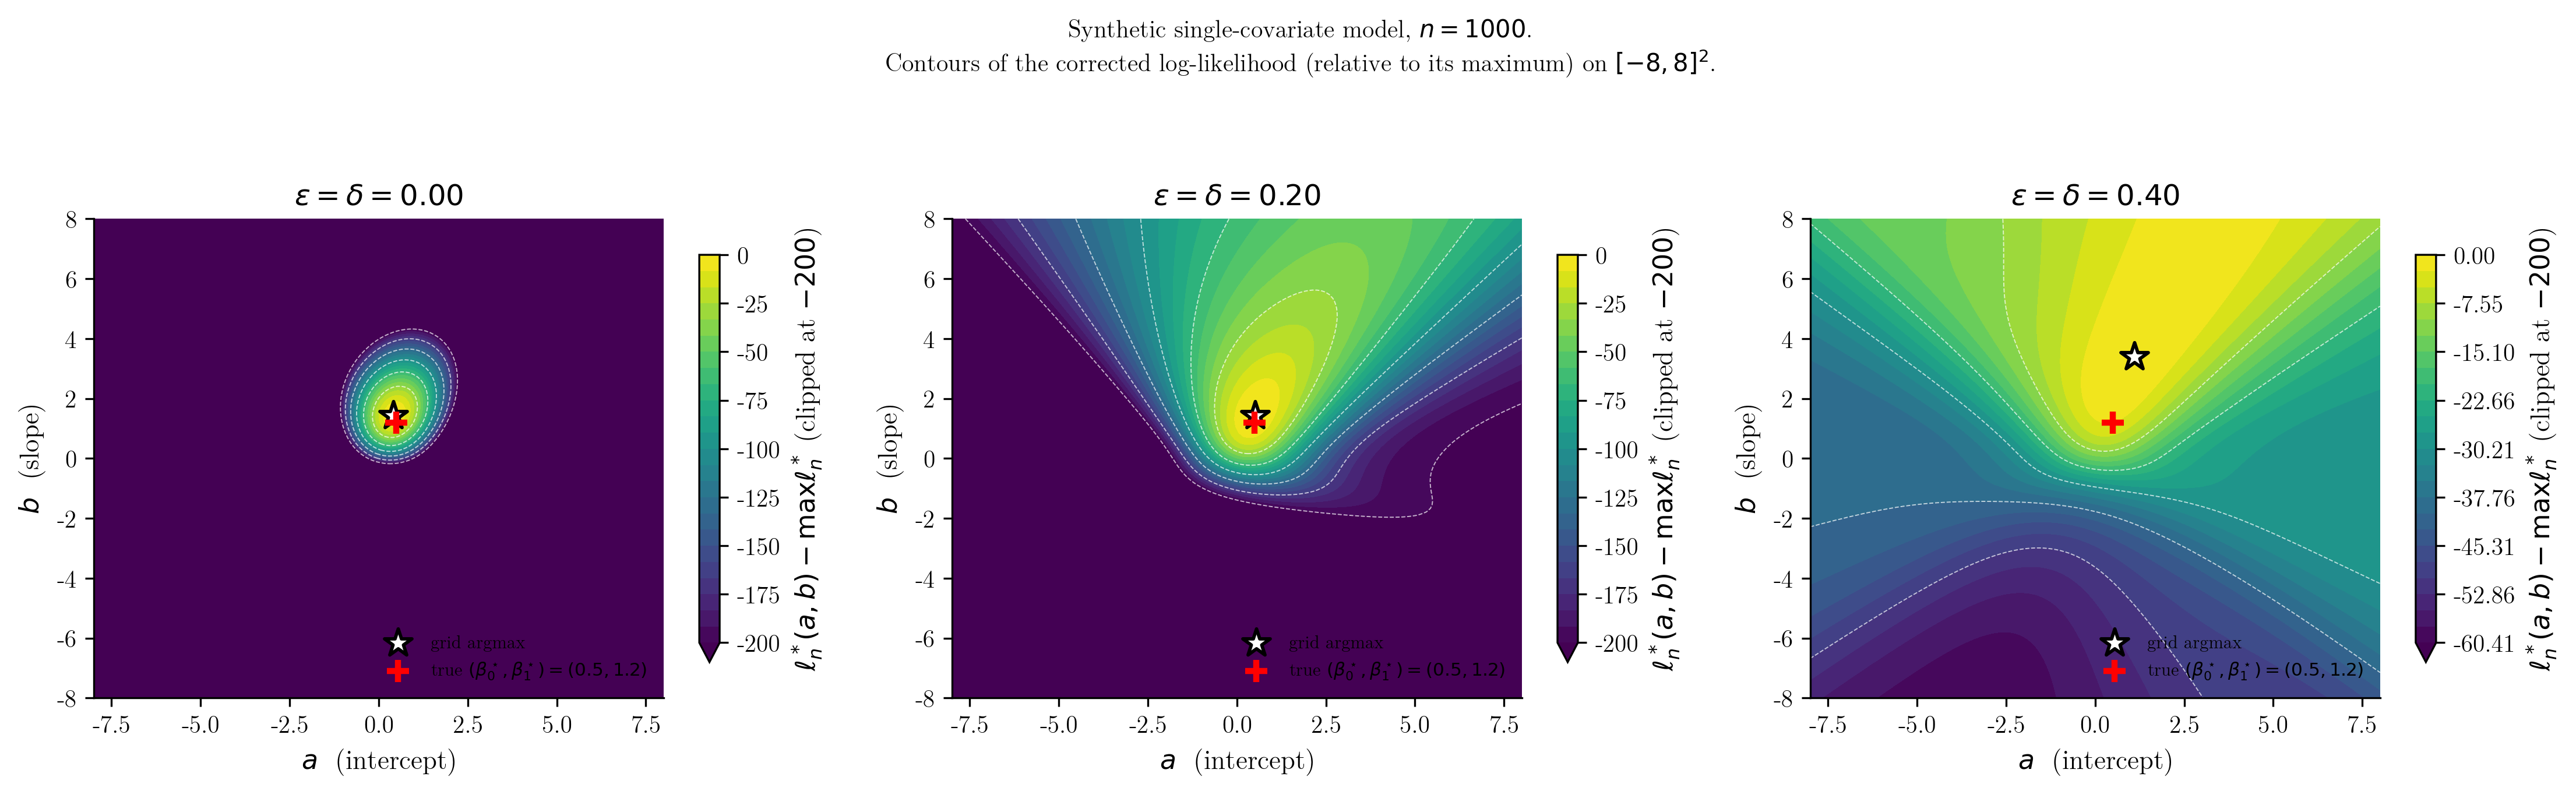

In [2]:
X, _ = make_synth(seed=SEED)
Xd_syn = sm.add_constant(X, has_constant='add')

# rebuild the clean labels we'll re-flip at each eps so panels are comparable
rng = np.random.default_rng(SEED)
x_syn = rng.standard_normal(1000)
y_clean = rng.binomial(1, H(0.5 + 1.2 * x_syn))

grid_n = 140
win = 8.0
a_grid = np.linspace(-win, win, grid_n)
b_grid = np.linspace(-win, win, grid_n)
A, B = np.meshgrid(a_grid, b_grid)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.6))
for ax, eps in zip(axes, [0.0, 0.20, 0.40]):
    if eps == 0.0:
        yh_eps = y_clean
    else:
        rng_flip = np.random.default_rng(SEED + 100 + int(eps * 100))
        yh_eps = flip_labels(y_clean, eps, eps, rng=rng_flip)

    Z = np.empty_like(A)
    for i in range(grid_n):
        for j in range(grid_n):
            Z[i, j] = -neg_logL(np.array([A[i, j], B[i, j]]), Xd_syn, yh_eps, eps, eps)
    Zc = Z - Z.max()
    vmin = max(Zc.min(), -200.0)
    levels = np.linspace(vmin, 0, 25)
    cf = ax.contourf(A, B, Zc, levels=levels, cmap='viridis', extend='min')
    ax.contour(A, B, Zc, levels=levels[::4], colors='white', linewidths=0.45, alpha=0.7)
    ij = np.unravel_index(np.argmax(Z), Z.shape)
    ax.scatter(A[ij], B[ij], s=140, marker='*',
               facecolor='white', edgecolor='black', linewidth=1.4,
               zorder=5, label='grid argmax')
    ax.scatter(0.5, 1.2, s=80, marker='+', color='red', linewidth=2.5, zorder=6,
               label=r'true $(\beta_0^\star, \beta_1^\star) = (0.5, 1.2)$')
    ax.set_xlabel(r'$a$  (intercept)')
    ax.set_ylabel(r'$b$  (slope)')
    ax.set_title(rf'$\varepsilon = \delta = {eps:.2f}$')
    ax.legend(loc='lower right', fontsize=7.5, framealpha=0.92)
    plt.colorbar(cf, ax=ax, shrink=0.85,
                 label=r'$\ell_n^*(a,b) - \max\ell_n^*$ (clipped at $-200$)')

fig.suptitle(
    'Synthetic single-covariate model, $n = 1000$.\n'
    'Contours of the corrected log-likelihood (relative to its maximum) on $[-8, 8]^2$.',
    fontsize=10,
)
fig.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

## 2. The breast-cancer multistart at $\varepsilon = \delta = 0.20$

We move to the four-predictor breast-cancer training fold (the same data and noise
rates as Section 5.3 of the report, at moderate noise). The cell below draws 200
random starts uniformly in $[-13, 13]^5$ and runs bounded L-BFGS-B from each.

In [3]:
EPS = 0.20
Xc, yhc = make_breast(eps=EPS, delta=EPS, seed=SEED)
Xd_bc = sm.add_constant(Xc, has_constant='add')
print(f'n = {Xc.shape[0]}, p = {Xc.shape[1]} predictors (+ intercept)')

fits = multistart(Xc, yhc, n_starts=200, eps=EPS, delta=EPS,
                  start_radius=13.0, bound=15.0, seed=SEED + 13)
interior = [f for f in fits if not f['on_bound'] and f['success']]
print(f'interior fits: {len(interior)} / 200 (the rest pin to the bound)')

xs = np.vstack([f['x'] for f in interior])
funs = np.array([f['fun'] for f in interior])
print(f'range of -log-likelihood across interior fits: '
      f'[{funs.min():.3f}, {funs.max():.3f}]  (spread = {funs.max() - funs.min():.3f})')
print(f'max ||x - centroid||: {np.linalg.norm(xs - xs.mean(0), axis=1).max():.3f}')

n = 398, p = 4 predictors (+ intercept)


interior fits: 175 / 200 (the rest pin to the bound)
range of -log-likelihood across interior fits: [206.295, 207.202]  (spread = 0.907)
max ||x - centroid||: 6.479


### Two distinct stationary points

Greedy clustering with a small tolerance shows the 175 interior fits collapse into
**exactly two clusters** -- not a continuous ridge.

In [4]:
def cluster_interior(xs, tol=0.05):
    n = len(xs)
    labels = -np.ones(n, dtype=int)
    centers = []
    for k in range(n):
        if labels[k] >= 0:
            continue
        c = len(centers)
        labels[k] = c
        for m in range(k + 1, n):
            if labels[m] < 0 and np.linalg.norm(xs[k] - xs[m]) < tol:
                labels[m] = c
        centers.append(xs[k])
    sizes = np.bincount(labels)
    return labels, np.array(centers), sizes

labels, centers, sizes = cluster_interior(xs, tol=0.05)
print(f'distinct interior stationary points: {len(centers)}')
for c in range(len(centers)):
    ll = -neg_logL(centers[c], Xd_bc, yhc, EPS, EPS)
    print(f'  cluster {c}: {sizes[c]} starts, l*_n = {ll:.4f}')
    print(f'    x = {centers[c]}')

# label the better one as beta_a (higher l*_n), the worse one as beta_b
lls = np.array([-neg_logL(c, Xd_bc, yhc, EPS, EPS) for c in centers])
order = np.argsort(-lls)  # best (highest l*_n) first
beta_a = centers[order[0]]
beta_b = centers[order[1]]
ll_a, ll_b = lls[order[0]], lls[order[1]]
size_a, size_b = sizes[order[0]], sizes[order[1]]
print()
print(f'beta_a (better, {size_a} starts, l*_n = {ll_a:.4f}): {beta_a}')
print(f'beta_b (worse,  {size_b} starts, l*_n = {ll_b:.4f}): {beta_b}')
print(f'||beta_a - beta_b|| = {np.linalg.norm(beta_a - beta_b):.3f}')
print(f'gap in -l*_n = {ll_a - ll_b:.4f}')

distinct interior stationary points: 2
  cluster 0: 119 starts, l*_n = -207.2019
    x = [  2.43767317  -9.3239271   -5.3924111   -2.38518038 -10.37882105]
  cluster 1: 56 starts, l*_n = -206.2952
    x = [ 0.14225342 -3.81979474 -1.26041635 -0.43882039 -4.5164055 ]

beta_a (better, 56 starts, l*_n = -206.2952): [ 0.14225342 -3.81979474 -1.26041635 -0.43882039 -4.5164055 ]
beta_b (worse,  119 starts, l*_n = -207.2019): [  2.43767317  -9.3239271   -5.3924111   -2.38518038 -10.37882105]
||beta_a - beta_b|| = 9.529
gap in -l*_n = 0.9067


## 3. Both are genuine strict local maxima

L-BFGS-B's stopping criterion is gradient-norm-based, so it converges to KKT points
(critical points), not necessarily to local maxima. A critical point of $\ell_n^*$ is a
local max iff the Hessian of $-\ell_n^*$ is positive-definite. We check both.

In [5]:
for name, b in [('beta_a (better)', beta_a), ('beta_b (worse)', beta_b)]:
    g = grad_L(b, Xd_bc, yhc, EPS, EPS)
    Hm = numeric_hess(b, Xd_bc, yhc, EPS, EPS)  # = Hess(-loglik), PD => local max of loglik
    eigs = np.sort(np.linalg.eigvalsh(Hm))
    print(f'{name}')
    print(f'  ||grad||           = {np.linalg.norm(g):.3e}')
    print(f'  Hess(-l*) eigvals  = {eigs}')
    print(f'  -> {(eigs > 1e-6).sum()} positive, {(eigs < -1e-6).sum()} negative')
    print(f'  -> strict local MAX of l*_n: {(eigs > 1e-6).all()}')
    print()

beta_a (better)
  ||grad||           = 9.455e-07
  Hess(-l*) eigvals  = [0.16427141 0.40472187 1.78452302 3.1617527  7.22577051]
  -> 5 positive, 0 negative
  -> strict local MAX of l*_n: True

beta_b (worse)
  ||grad||           = 6.581e-06
  Hess(-l*) eigvals  = [0.00225581 0.07202478 0.24852671 0.80828492 1.92070873]
  -> 5 positive, 0 negative
  -> strict local MAX of l*_n: True



Both are strict local maxima, but the smallest eigenvalue of $\widehat\beta_b$'s Hessian
is about **70$\times$ smaller** than that of $\widehat\beta_a$. $\widehat\beta_b$ is a
*soft* peak: the surface near it is almost flat along one direction.

### The single-panel diagnostic plot

The cleanest demonstration is a 1D slice between the two maxima, well zoomed.

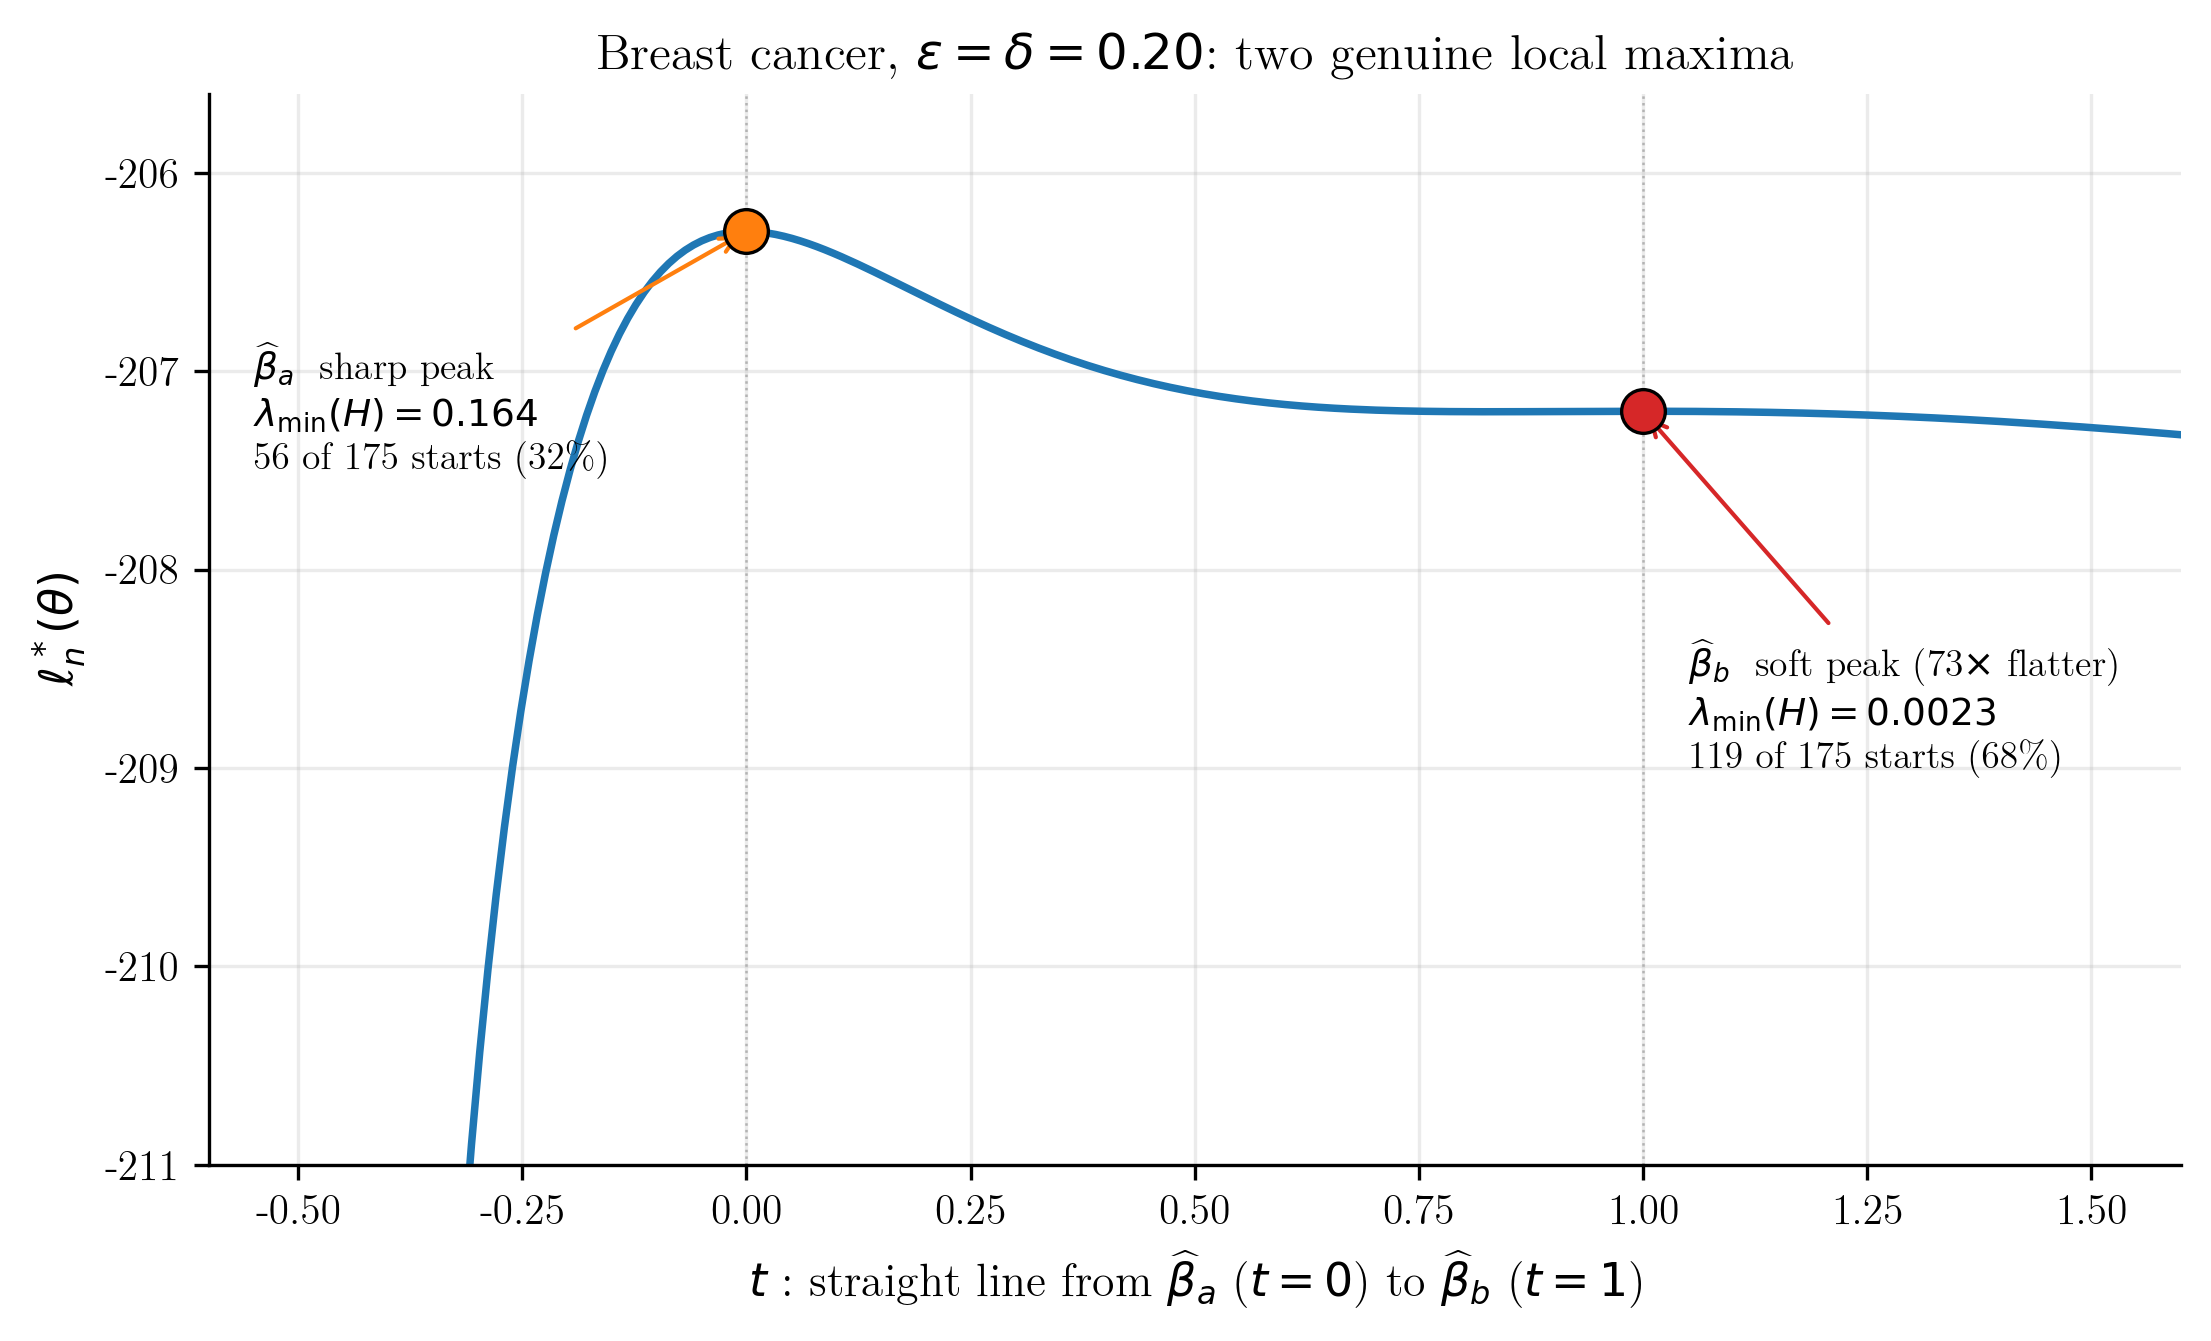

In [6]:
Ha = numeric_hess(beta_a, Xd_bc, yhc, EPS, EPS)
Hb = numeric_hess(beta_b, Xd_bc, yhc, EPS, EPS)
lam_a = np.linalg.eigvalsh(Ha).min()
lam_b = np.linalg.eigvalsh(Hb).min()

fig, ax = plt.subplots(figsize=(7.5, 4.6))
t_grid = np.linspace(-0.6, 1.6, 241)
ll_path = np.array([
    -neg_logL((1 - t) * beta_a + t * beta_b, Xd_bc, yhc, EPS, EPS)
    for t in t_grid
])
ax.plot(t_grid, ll_path, '-', color='C0', linewidth=1.8)
ax.scatter([0], [ll_a], s=110, color='C1', zorder=5, edgecolor='black', linewidth=0.8)
ax.scatter([1], [ll_b], s=110, color='C3', zorder=5, edgecolor='black', linewidth=0.8)
ax.annotate(
    rf'$\widehat\beta_a$  sharp peak' '\n'
    rf'$\lambda_{{\min}}(H) = {lam_a:.3f}$' '\n'
    rf'{size_a} of {len(interior)} starts ({100*size_a/len(interior):.0f}%)',
    xy=(0, ll_a), xytext=(-0.55, ll_a - 1.2),
    fontsize=9, ha='left',
    arrowprops=dict(arrowstyle='->', color='C1', lw=1.0),
)
ax.annotate(
    rf'$\widehat\beta_b$  soft peak ({lam_a/lam_b:.0f}$\times$ flatter)' '\n'
    rf'$\lambda_{{\min}}(H) = {lam_b:.4f}$' '\n'
    rf'{size_b} of {len(interior)} starts ({100*size_b/len(interior):.0f}%)',
    xy=(1, ll_b), xytext=(1.05, ll_b - 1.8),
    fontsize=9, ha='left',
    arrowprops=dict(arrowstyle='->', color='C3', lw=1.0),
)
ax.axvline(0, color='0.7', linewidth=0.6, linestyle=':')
ax.axvline(1, color='0.7', linewidth=0.6, linestyle=':')
ax.set_ylim(-211, -205.6)
ax.set_xlim(-0.6, 1.6)
ax.set_xlabel(r'$t$ : straight line from $\widehat\beta_a$ ($t=0$) to $\widehat\beta_b$ ($t=1$)')
ax.set_ylabel(r'$\ell_n^*(\theta)$')
ax.set_title(r'Breast cancer, $\varepsilon = \delta = 0.20$: two genuine local maxima')
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

### Detailed three-panel view

If the single 1D slice isn't convincing, we can also view each local max in *its own*
Hessian eigenbasis. This guarantees the local-max structure is visible -- the chosen
axes are the principal curvature directions at that point.

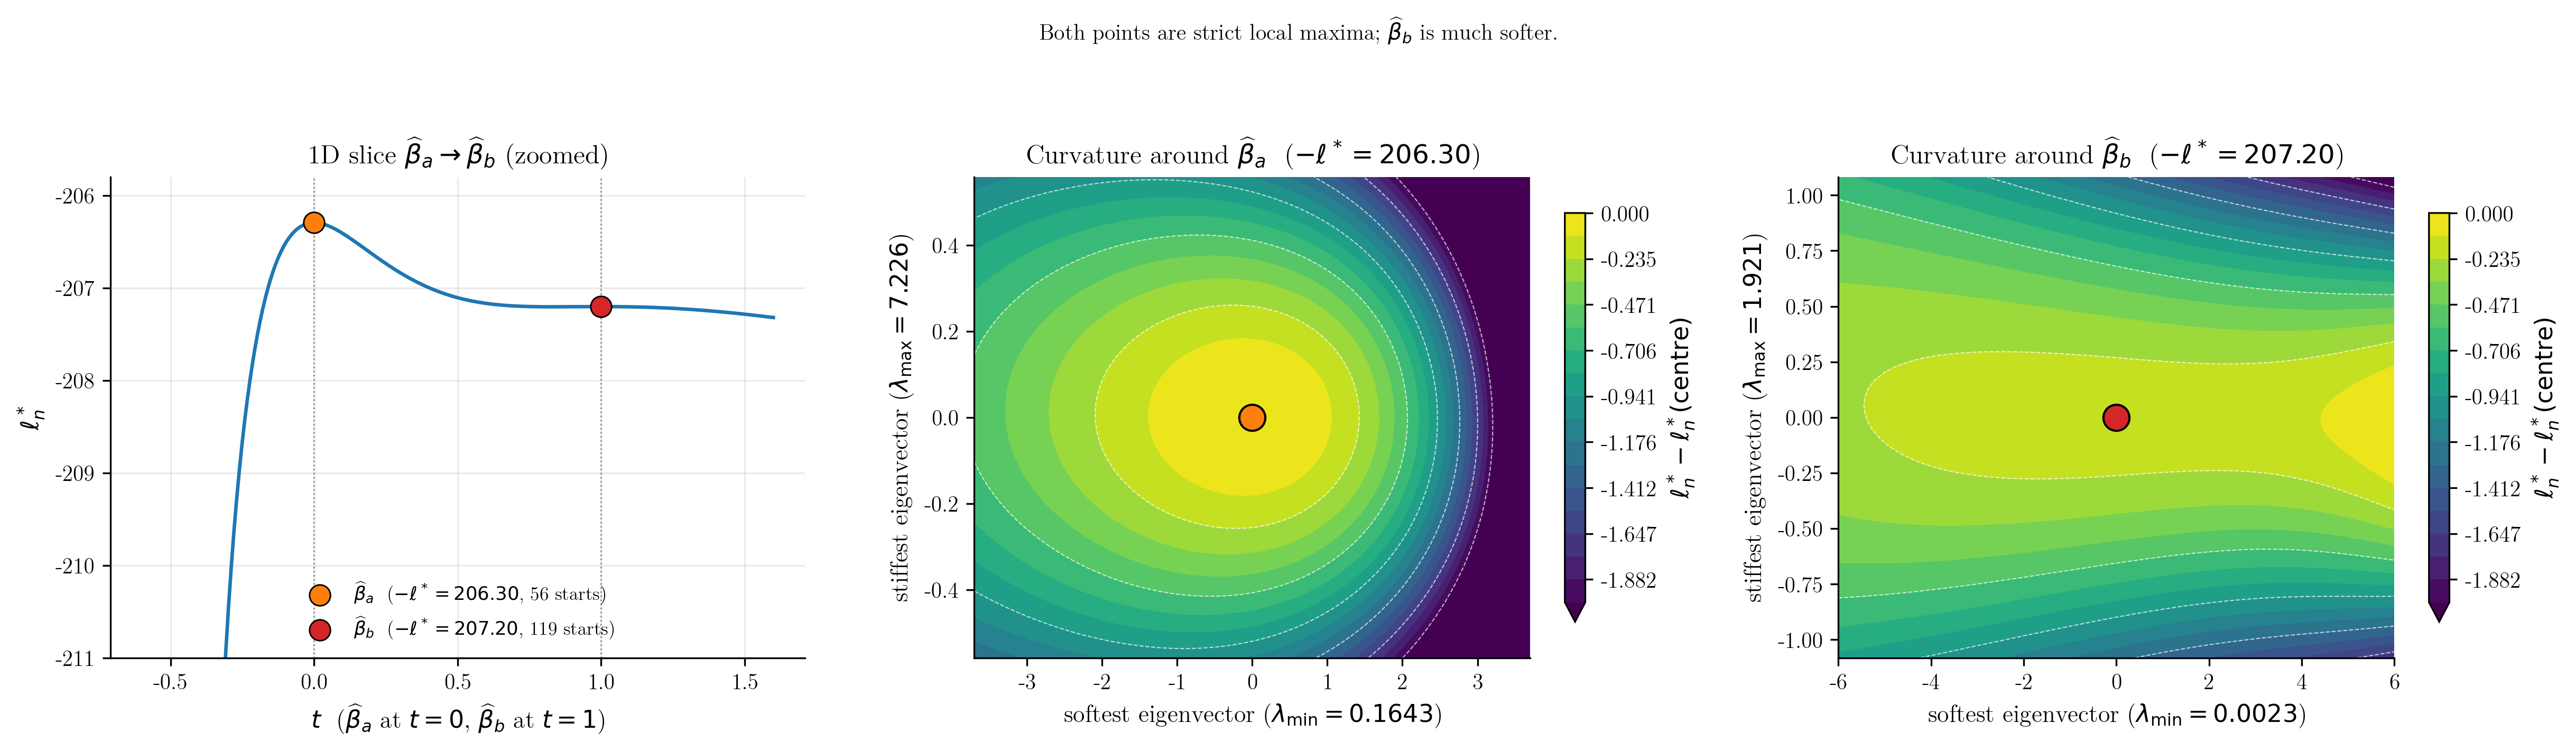

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))

# panel 0: 1D slice (without annotations, for compactness)
axes[0].plot(t_grid, ll_path, '-', color='C0', linewidth=1.6)
axes[0].axvline(0, color='0.55', linewidth=0.7, linestyle=':')
axes[0].axvline(1, color='0.55', linewidth=0.7, linestyle=':')
axes[0].scatter([0], [ll_a], s=90, color='C1', zorder=5,
                edgecolor='black', linewidth=0.7,
                label=rf'$\widehat\beta_a$  ($-\ell^* = {-ll_a:.2f}$, {size_a} starts)')
axes[0].scatter([1], [ll_b], s=90, color='C3', zorder=5,
                edgecolor='black', linewidth=0.7,
                label=rf'$\widehat\beta_b$  ($-\ell^* = {-ll_b:.2f}$, {size_b} starts)')
axes[0].set_ylim(-211, -205.8)
axes[0].set_xlabel(r'$t$  ($\widehat\beta_a$ at $t=0$, $\widehat\beta_b$ at $t=1$)')
axes[0].set_ylabel(r'$\ell_n^*$')
axes[0].set_title(r'1D slice $\widehat\beta_a \to \widehat\beta_b$ (zoomed)')
axes[0].legend(loc='lower center', fontsize=8.5, framealpha=0.92)
axes[0].grid(alpha=0.25)

for ax_i, b, name, color_, ll_pt in [
    (1, beta_a, r'\widehat\beta_a', 'C1', ll_a),
    (2, beta_b, r'\widehat\beta_b', 'C3', ll_b),
]:
    Hm = numeric_hess(b, Xd_bc, yhc, EPS, EPS)
    eigs, vecs = np.linalg.eigh(Hm)
    v_soft, v_stiff = vecs[:, 0], vecs[:, -1]
    r_soft = min(1.5 / np.sqrt(max(eigs[0], 1e-6)), 6.0)
    r_stiff = 1.5 / np.sqrt(max(eigs[-1], 1e-6))
    g = 60
    S, T = np.meshgrid(np.linspace(-r_soft, r_soft, g),
                       np.linspace(-r_stiff, r_stiff, g))
    Z = np.empty_like(S)
    for i in range(g):
        for j in range(g):
            theta = b + S[i, j] * v_soft + T[i, j] * v_stiff
            Z[i, j] = -neg_logL(theta, Xd_bc, yhc, EPS, EPS)
    Zc = Z - Z.max()
    levels = np.linspace(max(Zc.min(), -2.0), 0, 18)
    cf = axes[ax_i].contourf(S, T, Zc, levels=levels, cmap='viridis', extend='min')
    axes[ax_i].contour(S, T, Zc, levels=levels[::3], colors='white',
                       linewidths=0.5, alpha=0.7)
    axes[ax_i].scatter([0], [0], s=140, marker='o', facecolor=color_,
                       edgecolor='black', linewidth=1.0, zorder=5)
    axes[ax_i].set_xlabel(rf'softest eigenvector ($\lambda_{{\min}} = {eigs[0]:.4f}$)')
    axes[ax_i].set_ylabel(rf'stiffest eigenvector ($\lambda_{{\max}} = {eigs[-1]:.3f}$)')
    axes[ax_i].set_title(rf'Curvature around ${name}$  ($-\ell^* = {-ll_pt:.2f}$)')
    plt.colorbar(cf, ax=axes[ax_i], shrink=0.85,
                 label=r'$\ell_n^* - \ell_n^*({\rm centre})$')

fig.suptitle(
    'Both points are strict local maxima; $\\widehat\\beta_b$ is much softer.',
    fontsize=10,
)
fig.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

## 4. Why does the majority of starts converge to the worse local max?

Counterintuitive observation: even though most of $[-13, 13]^5$ is Euclidean-closer to
$\widehat\beta_a$, only 32% of starts land there. Basins of attraction depend on the
gradient field, not on geometric closeness.

### 4a. The two maxima are nearly collinear from the origin

$\widehat\beta_a$ and $\widehat\beta_b$ are roughly on the same ray, with $\widehat\beta_b$
about 2.5$\times$ further out.

In [8]:
cos_ab = np.dot(beta_a, beta_b) / (np.linalg.norm(beta_a) * np.linalg.norm(beta_b))
print(f'||beta_a|| = {np.linalg.norm(beta_a):.3f}')
print(f'||beta_b|| = {np.linalg.norm(beta_b):.3f}')
print(f'cos(angle between beta_a and beta_b from origin) = {cos_ab:.4f}')
print(f'angle = {np.degrees(np.arccos(cos_ab)):.2f} degrees')
print(f'||beta_b|| / ||beta_a|| = {np.linalg.norm(beta_b) / np.linalg.norm(beta_a):.2f}')

||beta_a|| = 6.065
||beta_b|| = 15.342
cos(angle between beta_a and beta_b from origin) = 0.9745
angle = 12.97 degrees
||beta_b|| / ||beta_a|| = 2.53


### 4b. Basins of attraction don't match Voronoi regions

If basins followed Euclidean closeness, the fraction of starts that converge to
$\widehat\beta_a$ would equal the fraction of the start cube closer to $\widehat\beta_a$.
It doesn't.

In [9]:
rng = np.random.default_rng(0)
samp = rng.uniform(-13, 13, size=(100_000, 5))
dA = np.linalg.norm(samp - beta_a, axis=1)
dB = np.linalg.norm(samp - beta_b, axis=1)
frac_voronoi_a = (dA < dB).mean()
frac_basin_a = size_a / (size_a + size_b)

print(f'Fraction of [-13,13]^5 closer to beta_a:       {frac_voronoi_a:.2%}')
print(f'Fraction of interior starts converging to a:   {frac_basin_a:.2%}')
print()
print(f'(So 91% closer to a in Euclidean distance,')
print(f'  but only 32% actually converge to a.)')

Fraction of [-13,13]^5 closer to beta_a:       91.48%
Fraction of interior starts converging to a:   32.00%

(So 91% closer to a in Euclidean distance,
  but only 32% actually converge to a.)


### 4c. The gradient points toward $\widehat\beta_b$ at random starts

For each random start $s$, the optimizer's first move is in direction $-\nabla(-\ell_n^*)(s)$,
i.e., $+\nabla\ell_n^*(s)$. We can ask: does this move align more with the direction
toward $\widehat\beta_a$ or with the direction toward $\widehat\beta_b$?

Across 200 random starts:
  mean cos(move, toward beta_a) = +0.351
  mean cos(move, toward beta_b) = +0.645
  fraction of starts where cos_b > cos_a = 99.50%

Histogram of (cos_b - cos_a) over 200 starts:


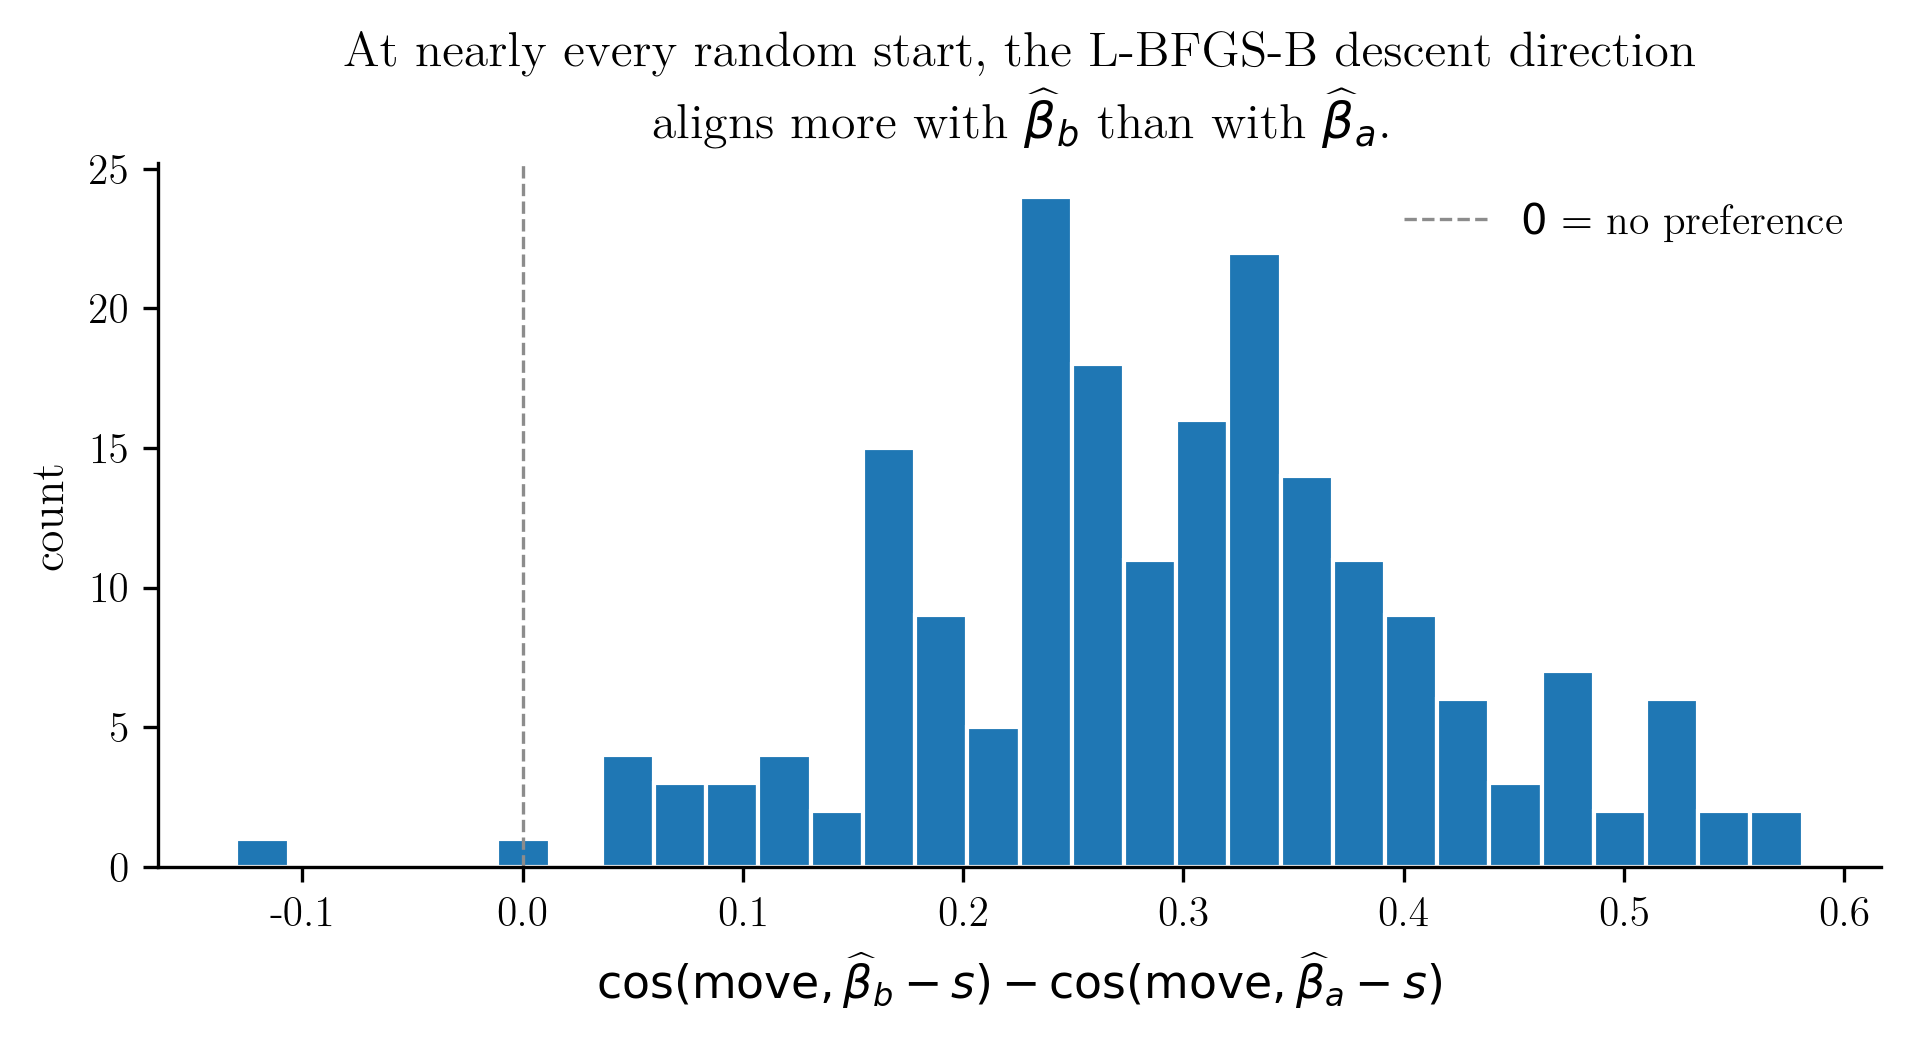

In [10]:
rng = np.random.default_rng(99)
n_probe = 200
cos_a, cos_b = [], []
for _ in range(n_probe):
    s = rng.uniform(-13, 13, size=5)
    g = grad_L(s, Xd_bc, yhc, EPS, EPS)  # grad of -loglik
    move = -g / np.linalg.norm(g)        # the optimizer moves along -g
    da = (beta_a - s) / np.linalg.norm(beta_a - s)
    db = (beta_b - s) / np.linalg.norm(beta_b - s)
    cos_a.append(np.dot(move, da))
    cos_b.append(np.dot(move, db))
cos_a = np.array(cos_a)
cos_b = np.array(cos_b)
print(f'Across {n_probe} random starts:')
print(f'  mean cos(move, toward beta_a) = {cos_a.mean():+.3f}')
print(f'  mean cos(move, toward beta_b) = {cos_b.mean():+.3f}')
print(f'  fraction of starts where cos_b > cos_a = {(cos_b > cos_a).mean():.2%}')
print()
print('Histogram of (cos_b - cos_a) over 200 starts:')
fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.hist(cos_b - cos_a, bins=30, color='C0', edgecolor='white')
ax.axvline(0, color='0.55', linewidth=0.8, linestyle='--',
           label=r'$0$ = no preference')
ax.set_xlabel(r'$\cos(\mathrm{move}, \widehat\beta_b - s) - \cos(\mathrm{move}, \widehat\beta_a - s)$')
ax.set_ylabel('count')
ax.set_title(
    'At nearly every random start, the L-BFGS-B descent direction\n'
    r'aligns more with $\widehat\beta_b$ than with $\widehat\beta_a$.')
ax.legend()
fig.tight_layout()
plt.show()

### 4d. The mechanism: near-separation drives the gradient

The breast-cancer data with these four predictors is near-separating. The clean MLE
wants to push $\eta_i = x_i^\top\beta \to \pm\infty$ along a particular direction.
That drive doesn't disappear when we add the noise correction; it is only partially
balanced by the $q_i$-floor.

Two equilibria along the same ray result:

- $\widehat\beta_a$: coefficients moderate, observations rarely at the floor. The
  Hessian is well-conditioned. This is a *sharp* peak with a narrow basin.
- $\widehat\beta_b$: coefficients much larger; many observations sit at the floor. The
  surface is *soft* in the direction along which the separation drive and the floor
  cancel exactly. The basin of attraction is wide.

A random start in $[-13, 13]^5$ is dropped into a gradient field that overwhelmingly
pushes toward the further-out balance point, so the optimizer rolls past
$\widehat\beta_a$ and only stops at $\widehat\beta_b$.

## 5. What this means for the report

The phrase in Section 3.5 of the report -- 'the corrected log-likelihood on this
near-separating sample no longer has a single sharp interior critical point but a
near-flat ridge' -- is a slight overstatement. The truth is finer: there are exactly
two distinct stationary points, both strict local maxima. One is sharp, one is soft.
The bound-hit diagnostic $\widehat p_{\mathrm{conv}}$ catches the boundary-failure mode
but does not flag local-max picking; the optimizer can 'succeed' (gradient $\to 0$)
and still land at a substantially inferior local max.

This notebook is not a part of the report; it is the exploratory analysis behind the
figure of Section 3.5 and the discussion in §3.3 about why the corrected objective is
not globally concave.